# UQ-SHRED Comprehensive Experiments: SST Dataset

This notebook implements the full experimental suite:

- **E1:** Reconstruction comparison (SHRED vs UQ-SHRED)
- **E2:** Calibration evaluation
- **E3:** Uncertainty-error relationship
- **E4:** Spatial uncertainty visualization
- **E5:** Temporal forecasting with UQ
- **E6:** Ablation study (sampling size)

All metrics: Relative Error, CRPS, Coverage, Sharpness, Correlation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.preprocessing import MinMaxScaler
from scipy.io import loadmat
import os
from datetime import datetime
import json

from processdata import load_data, TimeSeriesDataset
from models import SHRED, UQ_SHRED, UQ_Forecaster, fit, fit_uq, forecast_uq
import uq

# Settings
device = 'cuda' if torch.cuda.is_available() else 'cpu'
dataset_name = 'SST'
print(f'Using device: {device}')

# Results directory with dataset and datetime
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
results_dir = f'results/{dataset_name}_{timestamp}'
os.makedirs(results_dir, exist_ok=True)
print(f'Results will be saved to: {results_dir}')

# Reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Log configuration
config = {
    'dataset': dataset_name,
    'device': device,
    'seed': 42,
    'timestamp': timestamp
}

Using device: cuda
Results will be saved to: results/SST_20260224_111528


## Data Preparation

In [2]:
# Load data (returns only non-zero SST locations)
num_sensors = 3
lags = 52  # 1 year of weekly data

load_X = load_data(dataset_name)
n, m = load_X.shape
print(f'{dataset_name} data shape: {load_X.shape} (timesteps, spatial dim)')

# Load full SST data for spatial visualization
full_sst = loadmat('Data/SST_data.mat')['Z'].T
mean_sst = np.mean(full_sst, axis=0)
sst_locs = np.where(mean_sst != 0)[0]
print(f'Full SST shape: {full_sst.shape}, Non-zero locations: {len(sst_locs)}')

# Random sensor locations
sensor_locations = np.random.choice(m, size=num_sensors, replace=False)
print(f'Sensor locations: {sensor_locations}')

config.update({
    'num_sensors': num_sensors,
    'lags': lags,
    'data_shape': load_X.shape,
    'sensor_locations': sensor_locations.tolist()
})

SST data shape: (1400, 44219) (timesteps, spatial dim)
Full SST shape: (1400, 64800), Non-zero locations: 44219
Sensor locations: [28619  6515 13648]


In [3]:
# Train/valid/test split (80/10/10 sequential)
n_total = n - lags
train_size = int(0.8 * n_total)
valid_size = int(0.1 * n_total)

train_indices = np.arange(0, train_size)
valid_indices = np.arange(train_size, train_size + valid_size)
test_indices = np.arange(train_size + valid_size, n_total)

print(f'Train: {len(train_indices)}, Valid: {len(valid_indices)}, Test: {len(test_indices)}')

config.update({
    'split': {'train': len(train_indices), 'valid': len(valid_indices), 'test': len(test_indices)}
})

Train: 1078, Valid: 134, Test: 136


In [4]:
# Normalize
sc = MinMaxScaler()
sc = sc.fit(load_X[train_indices])
transformed_X = sc.transform(load_X)

# Generate input sequences
all_data_in = np.zeros((n - lags, lags, num_sensors))
for i in range(len(all_data_in)):
    all_data_in[i] = transformed_X[i:i+lags, sensor_locations]

# Create tensors
train_data_in = torch.tensor(all_data_in[train_indices], dtype=torch.float32).to(device)
valid_data_in = torch.tensor(all_data_in[valid_indices], dtype=torch.float32).to(device)
test_data_in = torch.tensor(all_data_in[test_indices], dtype=torch.float32).to(device)

train_data_out = torch.tensor(transformed_X[train_indices + lags - 1], dtype=torch.float32).to(device)
valid_data_out = torch.tensor(transformed_X[valid_indices + lags - 1], dtype=torch.float32).to(device)
test_data_out = torch.tensor(transformed_X[test_indices + lags - 1], dtype=torch.float32).to(device)

train_dataset = TimeSeriesDataset(train_data_in, train_data_out)
valid_dataset = TimeSeriesDataset(valid_data_in, valid_data_out)
test_dataset = TimeSeriesDataset(test_data_in, test_data_out)

print(f'Input shape: {train_data_in.shape}')
print(f'Output shape: {train_data_out.shape}')

Input shape: torch.Size([1078, 52, 3])
Output shape: torch.Size([1078, 44219])


---
# E1: Reconstruction Comparison

## Train SHRED (Baseline)

In [5]:
# Train SHRED
shred = SHRED(num_sensors, m, hidden_size=64, hidden_layers=2, l1=350, l2=400, dropout=0.1).to(device)
shred_errors = fit(shred, train_dataset, valid_dataset, batch_size=64, num_epochs=200, lr=1e-3, verbose=True, patience=5)

config['shred'] = {
    'hidden_size': 64,
    'hidden_layers': 2,
    'l1': 350,
    'l2': 400,
    'dropout': 0.1,
    'batch_size': 64,
    'num_epochs': 200,
    'lr': 1e-3,
    'patience': 5
}

Training epoch 1
Error tensor(0.4758, device='cuda:0')
Training epoch 20
Error tensor(0.2183, device='cuda:0')
Training epoch 40
Error tensor(0.2127, device='cuda:0')
Training epoch 60
Error tensor(0.2127, device='cuda:0')
Training epoch 80
Error tensor(0.2092, device='cuda:0')
Training epoch 100
Error tensor(0.2100, device='cuda:0')
Training epoch 120
Error tensor(0.2076, device='cuda:0')
Training epoch 140
Error tensor(0.2102, device='cuda:0')
Training epoch 160
Error tensor(0.2120, device='cuda:0')
Training epoch 180
Error tensor(0.2170, device='cuda:0')
Training epoch 200
Error tensor(0.2178, device='cuda:0')


In [6]:
# SHRED test error
shred.eval()
with torch.no_grad():
    shred_recon = shred(test_dataset.X)
    shred_error = (torch.linalg.norm(shred_recon - test_dataset.Y) / torch.linalg.norm(test_dataset.Y)).item()
print(f'SHRED Test Relative Error: {shred_error:.4f}')

SHRED Test Relative Error: 0.2263


## Train UQ-SHRED

In [7]:
# Train UQ-SHRED
uq_shred = UQ_SHRED(num_sensors, m, hidden_size=64, hidden_layers=2, l1=350, l2=400, dropout=0.1, noise_dim=50).to(device)
uq_errors = fit_uq(uq_shred, train_dataset, valid_dataset, batch_size=64, num_epochs=200, lr=1e-3, verbose=True, patience=5)

config['uq_shred'] = {
    'hidden_size': 64,
    'hidden_layers': 2,
    'l1': 350,
    'l2': 400,
    'dropout': 0.1,
    'noise_dim': 50,
    'batch_size': 64,
    'num_epochs': 200,
    'lr': 1e-3,
    'patience': 5
}

Epoch 1: error=0.5118
Epoch 20: error=0.2278
Epoch 40: error=0.2214
Epoch 60: error=0.2212
Epoch 80: error=0.2154
Epoch 100: error=0.2124
Epoch 120: error=0.2168
Epoch 140: error=0.2133
Epoch 160: error=0.2163
Epoch 180: error=0.2169
Epoch 200: error=0.2153


In [8]:
# UQ-SHRED test error (mean and median predictions)
uq_shred.eval()
samples = uq_shred.sample(test_dataset.X, n_samples=200)
samples_np = samples.cpu().numpy()

mean_recon = samples.mean(dim=0)
median_recon_np = np.median(samples_np, axis=0)
median_recon = torch.tensor(median_recon_np, dtype=torch.float32).to(device)
std_recon = samples.std(dim=0)

uq_mean_error = (torch.linalg.norm(mean_recon - test_dataset.Y) / torch.linalg.norm(test_dataset.Y)).item()
uq_median_error = (torch.linalg.norm(median_recon - test_dataset.Y) / torch.linalg.norm(test_dataset.Y)).item()

print(f'UQ-SHRED Mean Reconstruction Error: {uq_mean_error:.4f}')
print(f'UQ-SHRED Median Reconstruction Error: {uq_median_error:.4f}')
print(f'Average uncertainty (std): {std_recon.mean():.4f}')

UQ-SHRED Mean Reconstruction Error: 0.2269
UQ-SHRED Median Reconstruction Error: 0.2289
Average uncertainty (std): 0.0636


## E1 Metrics

In [9]:
# Compute all E1 metrics
crps_score = uq.crps(samples, test_dataset.Y)
sharp = uq.sharpness(samples, conf=0.95)
cal_scores = uq.calibration_scores(samples, test_dataset.Y, levels=[0.5, 0.7, 0.9, 0.95, 0.99])

# Uncertainty-error correlation
errors = torch.abs(test_dataset.Y - mean_recon).flatten().cpu().numpy()
stds = std_recon.flatten().cpu().numpy()
corr = np.corrcoef(stds, errors)[0, 1]

print('\n=== E1: Reconstruction Metrics ===')
print(f'SHRED Relative Error:       {shred_error:.4f}')
print(f'UQ-SHRED Mean Error:        {uq_mean_error:.4f}')
print(f'UQ-SHRED Median Error:      {uq_median_error:.4f}')
print(f'CRPS:                       {crps_score:.4f}')
print(f'Sharpness (95% CI):         {sharp:.4f}')
print(f'Coverage (95% CI):          {cal_scores[0.95]*100:.1f}%')
print(f'UQ-Error Correlation:       {corr:.3f}')


=== E1: Reconstruction Metrics ===
SHRED Relative Error:       0.2263
UQ-SHRED Mean Error:        0.2269
UQ-SHRED Median Error:      0.2289
CRPS:                       0.0622
Sharpness (95% CI):         0.2440
Coverage (95% CI):          74.9%
UQ-Error Correlation:       0.211


## E1 Visualization: Time Series Comparison

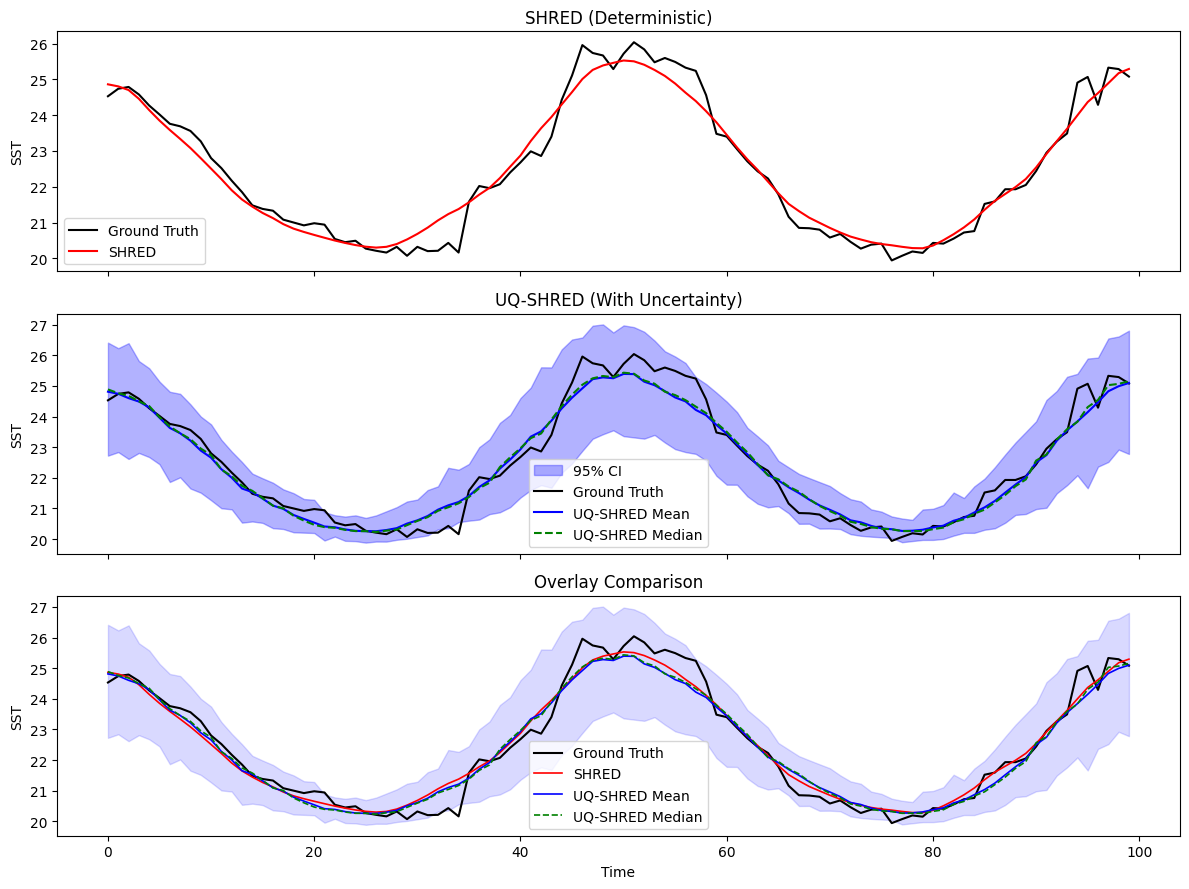

In [10]:
# Inverse transform for plotting
shred_recon_np = sc.inverse_transform(shred_recon.cpu().numpy())
test_truth_np = sc.inverse_transform(test_dataset.Y.cpu().numpy())
samples_orig = np.array([sc.inverse_transform(s) for s in samples_np])
mean_orig = samples_orig.mean(axis=0)
median_orig = np.median(samples_orig, axis=0)
lower_orig = np.percentile(samples_orig, 2.5, axis=0)
upper_orig = np.percentile(samples_orig, 97.5, axis=0)

# Three-panel comparison
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
idx = sensor_locations[0]
t = np.arange(100)

# SHRED (deterministic)
axes[0].plot(t, test_truth_np[:100, idx], 'k-', label='Ground Truth')
axes[0].plot(t, shred_recon_np[:100, idx], 'r-', label='SHRED')
axes[0].set_ylabel('SST')
axes[0].legend()
axes[0].set_title('SHRED (Deterministic)')

# UQ-SHRED (with uncertainty, mean + median)
axes[1].fill_between(t, lower_orig[:100, idx], upper_orig[:100, idx], alpha=0.3, color='blue', label='95% CI')
axes[1].plot(t, test_truth_np[:100, idx], 'k-', label='Ground Truth')
axes[1].plot(t, mean_orig[:100, idx], 'b-', label='UQ-SHRED Mean')
axes[1].plot(t, median_orig[:100, idx], 'g--', label='UQ-SHRED Median')
axes[1].set_ylabel('SST')
axes[1].legend()
axes[1].set_title('UQ-SHRED (With Uncertainty)')

# Overlay comparison
axes[2].plot(t, test_truth_np[:100, idx], 'k-', linewidth=1.5, label='Ground Truth')
axes[2].plot(t, shred_recon_np[:100, idx], 'r-', linewidth=1.2, label='SHRED')
axes[2].plot(t, mean_orig[:100, idx], 'b-', linewidth=1.2, label='UQ-SHRED Mean')
axes[2].plot(t, median_orig[:100, idx], 'g--', linewidth=1.2, label='UQ-SHRED Median')
axes[2].fill_between(t, lower_orig[:100, idx], upper_orig[:100, idx], alpha=0.15, color='blue')
axes[2].set_xlabel('Time')
axes[2].set_ylabel('SST')
axes[2].legend()
axes[2].set_title('Overlay Comparison')

plt.tight_layout()
plt.savefig(f'{results_dir}/E1_reconstruction_comparison.png', dpi=150)
plt.show()

---
# E2: Calibration

In [11]:
# Calibration scores (already computed above)
print('\n=== E2: Calibration Scores ===')
print('Coverage (expected → observed):')
for level, obs in cal_scores.items():
    print(f'  {level*100:.0f}% CI → {obs*100:.1f}% coverage')


=== E2: Calibration Scores ===
Coverage (expected → observed):
  50% CI → 33.9% coverage
  70% CI → 48.7% coverage
  90% CI → 67.9% coverage
  95% CI → 74.9% coverage
  99% CI → 83.3% coverage


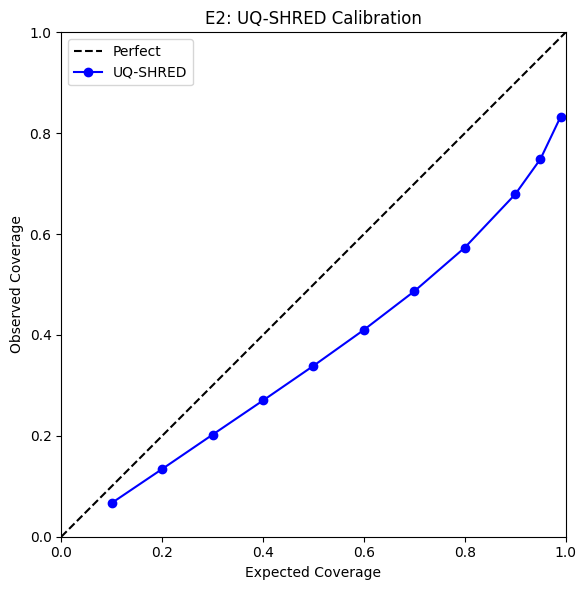

In [12]:
# Calibration diagram
fig, ax = plt.subplots(figsize=(6, 6))
uq.plot_calibration(samples, test_dataset.Y, ax=ax)
ax.set_title('E2: UQ-SHRED Calibration')
plt.tight_layout()
plt.savefig(f'{results_dir}/E2_calibration_diagram.png', dpi=150)
plt.show()

---
# E3: Uncertainty–Error Relationship

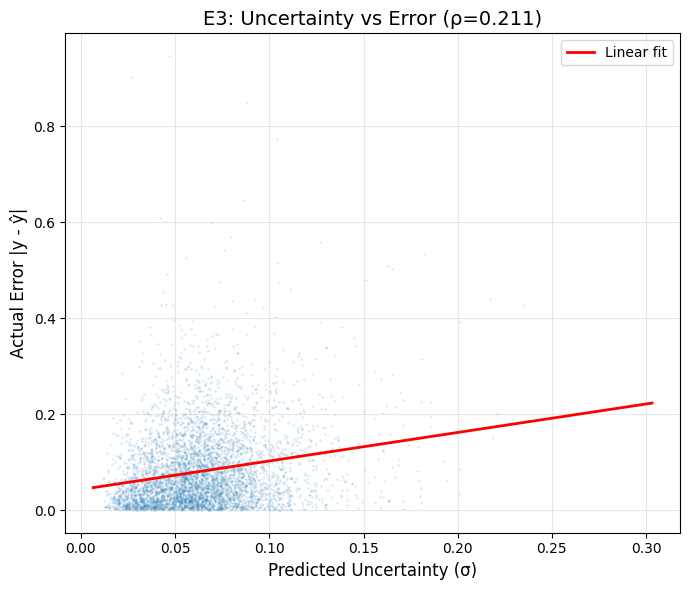


=== E3: Uncertainty-Error Correlation ===
Correlation ρ: 0.2107


In [13]:
# Subsample for plotting
idx_sample = np.random.choice(len(errors), min(5000, len(errors)), replace=False)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(stds[idx_sample], errors[idx_sample], alpha=0.1, s=1)

# Trend line
z = np.polyfit(stds[idx_sample], errors[idx_sample], 1)
p = np.poly1d(z)
x_line = np.linspace(stds.min(), stds.max(), 100)
ax.plot(x_line, p(x_line), 'r-', linewidth=2, label=f'Linear fit')

ax.set_xlabel('Predicted Uncertainty (σ)', fontsize=12)
ax.set_ylabel('Actual Error |y - ŷ|', fontsize=12)
ax.set_title(f'E3: Uncertainty vs Error (ρ={corr:.3f})', fontsize=14)
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{results_dir}/E3_uncertainty_vs_error.png', dpi=150)
plt.show()

print(f'\n=== E3: Uncertainty-Error Correlation ===' )
print(f'Correlation ρ: {corr:.4f}')

---
# E4: Spatial Uncertainty

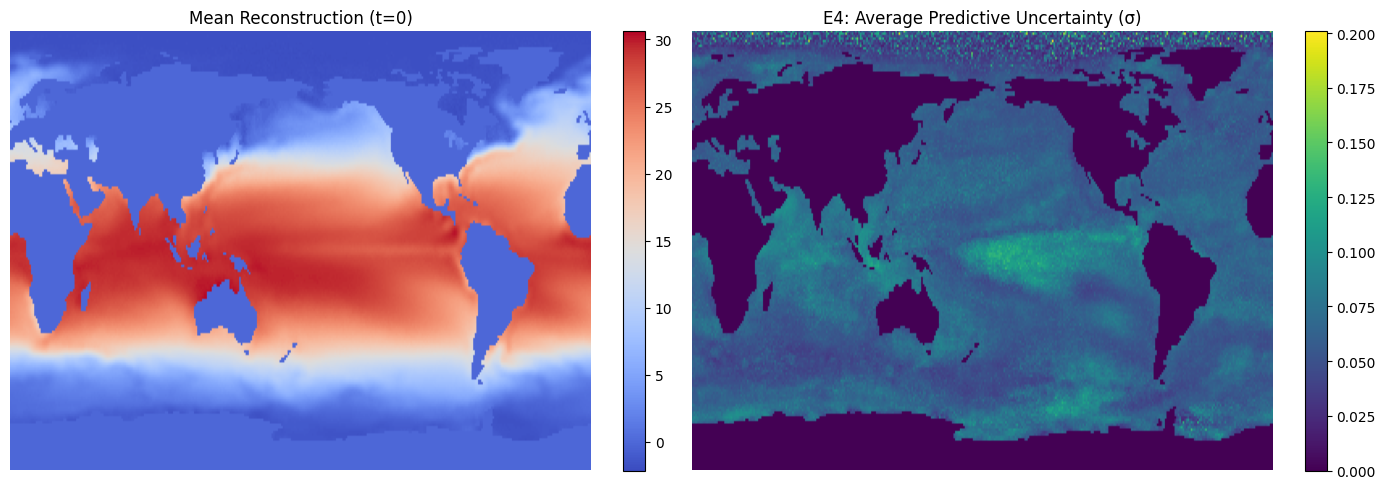


=== E4: Spatial Uncertainty Statistics ===
Mean uncertainty: 0.0636
Max uncertainty:  0.2008
Min uncertainty:  0.0143


In [14]:
# Helper function to map to full spatial domain
def map_to_full_sst(data_1d):
    """Maps reduced SST data (sst_locs only) back to full 180x360 grid"""
    full_data = np.zeros(180 * 360)
    full_data[sst_locs] = data_1d
    return full_data.reshape(180, 360)

# Compute spatial average uncertainty
avg_std = std_recon.cpu().numpy().mean(axis=0)  # Average over test set
spatial_std = map_to_full_sst(avg_std)

# Plot spatial uncertainty
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Mean prediction at a single timestep
mean_snapshot = map_to_full_sst(mean_orig[0])
im1 = axes[0].imshow(mean_snapshot, aspect='auto', cmap='coolwarm')
axes[0].set_title('Mean Reconstruction (t=0)')
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0], fraction=0.046)

# Right: Spatial uncertainty (avg std)
im2 = axes[1].imshow(spatial_std, aspect='auto', cmap='viridis')
axes[1].set_title('E4: Average Predictive Uncertainty (σ)')
axes[1].axis('off')
plt.colorbar(im2, ax=axes[1], fraction=0.046)

plt.tight_layout()
plt.savefig(f'{results_dir}/E4_spatial_uncertainty.png', dpi=150)
plt.show()

print('\n=== E4: Spatial Uncertainty Statistics ===')
print(f'Mean uncertainty: {avg_std.mean():.4f}')
print(f'Max uncertainty:  {avg_std.max():.4f}')
print(f'Min uncertainty:  {avg_std.min():.4f}')

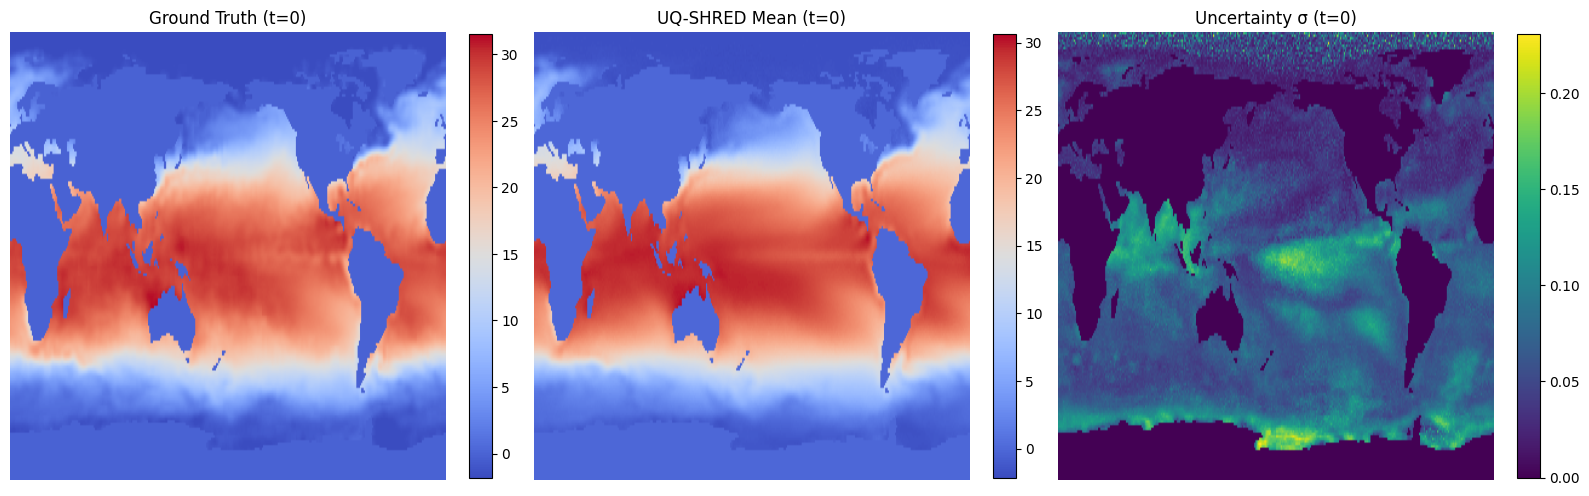

In [15]:
# Additional E4 visualization: Truth vs Mean vs Uncertainty
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

truth_snapshot = map_to_full_sst(test_truth_np[0])
std_snapshot = map_to_full_sst(std_recon.cpu().numpy()[0])

im1 = axes[0].imshow(truth_snapshot, aspect='auto', cmap='coolwarm')
axes[0].set_title('Ground Truth (t=0)')
axes[0].axis('off')
plt.colorbar(im1, ax=axes[0], fraction=0.046)

im2 = axes[1].imshow(mean_snapshot, aspect='auto', cmap='coolwarm')
axes[1].set_title('UQ-SHRED Mean (t=0)')
axes[1].axis('off')
plt.colorbar(im2, ax=axes[1], fraction=0.046)

im3 = axes[2].imshow(std_snapshot, aspect='auto', cmap='viridis')
axes[2].set_title('Uncertainty σ (t=0)')
axes[2].axis('off')
plt.colorbar(im3, ax=axes[2], fraction=0.046)

plt.tight_layout()
plt.savefig(f'{results_dir}/E4_spatial_snapshot.png', dpi=150)
plt.show()

---
# E5: Temporal Forecasting

In [16]:
# Prepare forecaster training data
sensor_data = transformed_X[:, sensor_locations]  # (n, num_sensors)

forecast_in = np.zeros((n - lags, lags, num_sensors))
forecast_out = np.zeros((n - lags, num_sensors))
for i in range(n - lags):
    forecast_in[i] = sensor_data[i:i+lags]
    forecast_out[i] = sensor_data[i+lags]

train_fc_in = torch.tensor(forecast_in[train_indices], dtype=torch.float32).to(device)
train_fc_out = torch.tensor(forecast_out[train_indices], dtype=torch.float32).to(device)
valid_fc_in = torch.tensor(forecast_in[valid_indices], dtype=torch.float32).to(device)
valid_fc_out = torch.tensor(forecast_out[valid_indices], dtype=torch.float32).to(device)

train_fc_dataset = TimeSeriesDataset(train_fc_in, train_fc_out)
valid_fc_dataset = TimeSeriesDataset(valid_fc_in, valid_fc_out)

# Train deterministic SHRED forecaster
print('Training deterministic SHRED forecaster...')
shred_forecaster = SHRED(num_sensors, num_sensors, hidden_size=64, hidden_layers=2, l1=100, l2=150, dropout=0.1).to(device)
fc_shred_errors = fit(shred_forecaster, train_fc_dataset, valid_fc_dataset, batch_size=64, num_epochs=200, lr=1e-3, verbose=True, patience=5)

Training deterministic SHRED forecaster...
Training epoch 1
Error tensor(0.5765, device='cuda:0')
Training epoch 20
Error tensor(0.1208, device='cuda:0')
Training epoch 40
Error tensor(0.1125, device='cuda:0')
Training epoch 60
Error tensor(0.1006, device='cuda:0')
Training epoch 80
Error tensor(0.1172, device='cuda:0')
Training epoch 100
Error tensor(0.0945, device='cuda:0')
Training epoch 120
Error tensor(0.0929, device='cuda:0')
Training epoch 140
Error tensor(0.0899, device='cuda:0')
Training epoch 160
Error tensor(0.0841, device='cuda:0')
Training epoch 180
Error tensor(0.0799, device='cuda:0')
Training epoch 200
Error tensor(0.0805, device='cuda:0')


In [17]:
# Train UQ-Forecaster
print('Training UQ-Forecaster...')
forecaster = UQ_Forecaster(input_size=num_sensors, hidden_size=64, hidden_layers=2, noise_dim=50).to(device)
fc_errors = fit_uq(forecaster, train_fc_dataset, valid_fc_dataset, batch_size=64, num_epochs=200, lr=1e-3, verbose=True, patience=5)

Training UQ-Forecaster...
Epoch 1: error=0.6040
Epoch 20: error=0.1281
Epoch 40: error=0.1111
Epoch 60: error=0.1077
Epoch 80: error=0.1062
Epoch 100: error=0.0982
Epoch 120: error=0.0931
Epoch 140: error=0.0863
Epoch 160: error=0.0825
Epoch 180: error=0.0783
Epoch 200: error=0.0806


In [18]:
# Generate forecast trajectories
horizon = 50
initial = test_data_in[0:1]

# Deterministic SHRED forecast
shred_forecaster.eval()
with torch.no_grad():
    history = initial.clone()
    shred_traj = []
    for t in range(horizon):
        next_val = shred_forecaster(history)
        shred_traj.append(next_val.cpu().numpy().squeeze())
        history = torch.cat([history[:, 1:, :], next_val.unsqueeze(1)], dim=1)
shred_traj = np.array(shred_traj)

# UQ forecast samples
uq_traj_samples = forecaster.sample_trajectory(initial, horizon=horizon, n_samples=100)
uq_traj_samples = uq_traj_samples.squeeze(1).cpu().numpy()

mean_traj = uq_traj_samples.mean(axis=0)
median_traj = np.median(uq_traj_samples, axis=0)
std_traj = uq_traj_samples.std(axis=0)
lower_traj = np.percentile(uq_traj_samples, 2.5, axis=0)
upper_traj = np.percentile(uq_traj_samples, 97.5, axis=0)

# Ground truth
start_idx = test_indices[0] + lags
gt_future = sensor_data[start_idx:start_idx+horizon]

# Forecast errors
shred_fc_error = np.linalg.norm(shred_traj - gt_future) / np.linalg.norm(gt_future)
uq_mean_fc_error = np.linalg.norm(mean_traj - gt_future) / np.linalg.norm(gt_future)
uq_median_fc_error = np.linalg.norm(median_traj - gt_future) / np.linalg.norm(gt_future)

print('\n=== E5: Forecast Errors ===')
print(f'SHRED forecast error:     {shred_fc_error:.4f}')
print(f'UQ mean forecast error:   {uq_mean_fc_error:.4f}')
print(f'UQ median forecast error: {uq_median_fc_error:.4f}')


=== E5: Forecast Errors ===
SHRED forecast error:     0.3731
UQ mean forecast error:   0.1694
UQ median forecast error: 0.1718


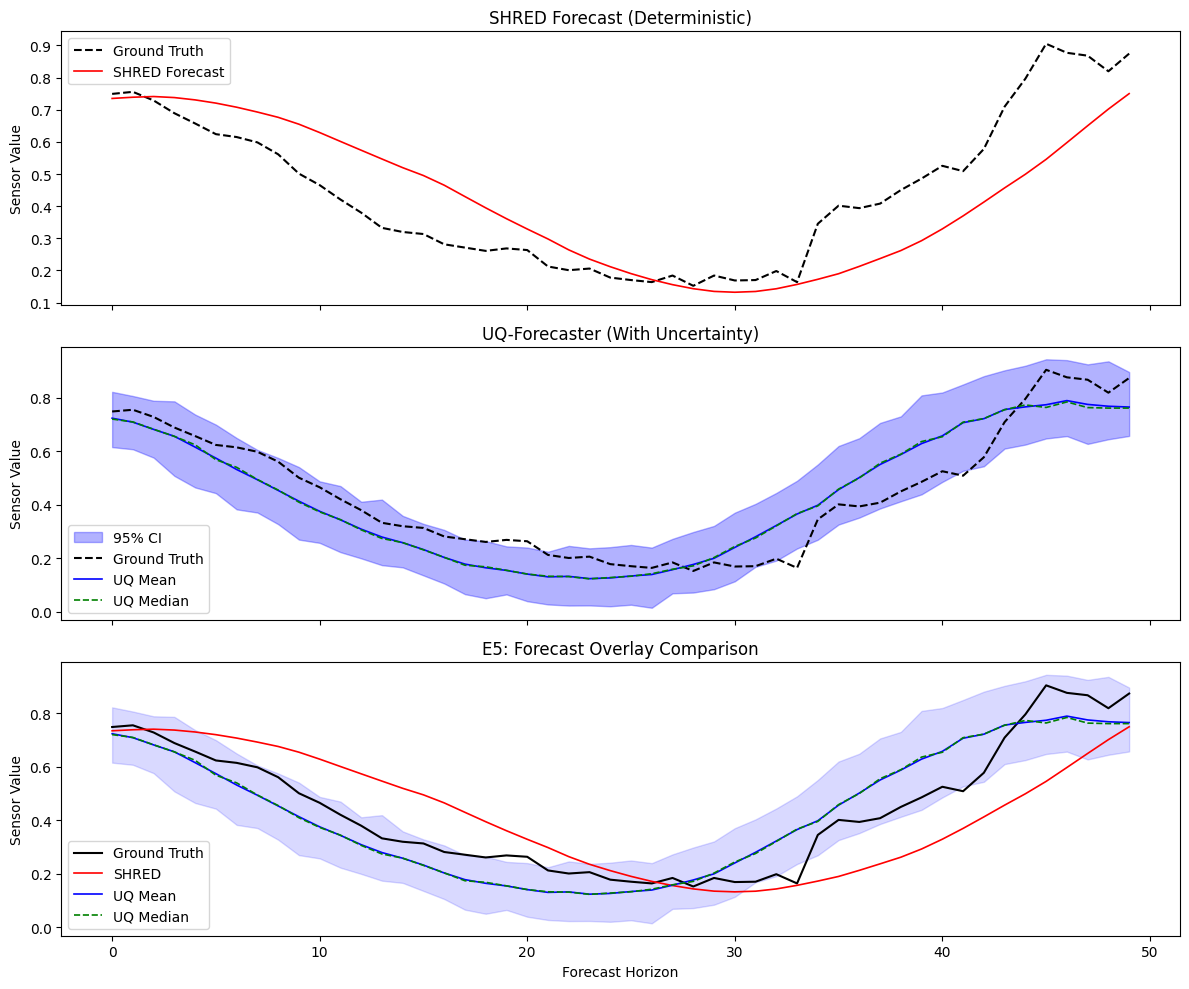

In [19]:
# E5 Visualization: Forecast comparison
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
t = np.arange(horizon)
sensor_idx = 0

# SHRED deterministic forecast
axes[0].plot(t, gt_future[:, sensor_idx], 'k--', linewidth=1.5, label='Ground Truth')
axes[0].plot(t, shred_traj[:, sensor_idx], 'r-', linewidth=1.2, label='SHRED Forecast')
axes[0].set_ylabel('Sensor Value')
axes[0].legend()
axes[0].set_title('SHRED Forecast (Deterministic)')

# UQ-SHRED forecast
axes[1].fill_between(t, lower_traj[:, sensor_idx], upper_traj[:, sensor_idx],
                alpha=0.3, color='blue', label='95% CI')
axes[1].plot(t, gt_future[:, sensor_idx], 'k--', linewidth=1.5, label='Ground Truth')
axes[1].plot(t, mean_traj[:, sensor_idx], 'b-', linewidth=1.2, label='UQ Mean')
axes[1].plot(t, median_traj[:, sensor_idx], 'g--', linewidth=1.2, label='UQ Median')
axes[1].set_ylabel('Sensor Value')
axes[1].legend()
axes[1].set_title('UQ-Forecaster (With Uncertainty)')

# Overlay
axes[2].plot(t, gt_future[:, sensor_idx], 'k-', linewidth=1.5, label='Ground Truth')
axes[2].plot(t, shred_traj[:, sensor_idx], 'r-', linewidth=1.2, label='SHRED')
axes[2].plot(t, mean_traj[:, sensor_idx], 'b-', linewidth=1.2, label='UQ Mean')
axes[2].plot(t, median_traj[:, sensor_idx], 'g--', linewidth=1.2, label='UQ Median')
axes[2].fill_between(t, lower_traj[:, sensor_idx], upper_traj[:, sensor_idx], alpha=0.15, color='blue')
axes[2].set_xlabel('Forecast Horizon')
axes[2].set_ylabel('Sensor Value')
axes[2].legend()
axes[2].set_title('E5: Forecast Overlay Comparison')

plt.tight_layout()
plt.savefig(f'{results_dir}/E5_forecast_comparison.png', dpi=150)
plt.show()

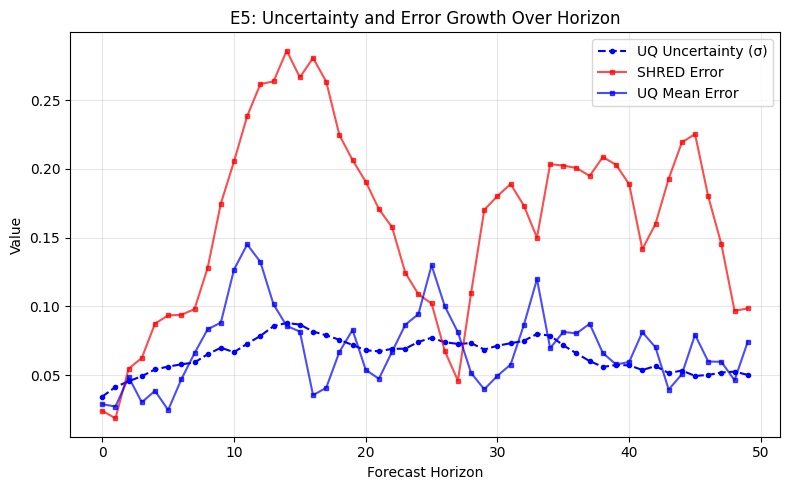

In [20]:
# E5: Uncertainty growth over horizon
avg_std_horizon = std_traj.mean(axis=1)
shred_error_horizon = np.abs(shred_traj - gt_future).mean(axis=1)
uq_error_horizon = np.abs(mean_traj - gt_future).mean(axis=1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(np.arange(horizon), avg_std_horizon, 'b--', marker='o', markersize=3, label='UQ Uncertainty (σ)')
ax.plot(np.arange(horizon), shred_error_horizon, 'r-', marker='s', markersize=3, alpha=0.7, label='SHRED Error')
ax.plot(np.arange(horizon), uq_error_horizon, 'b-', marker='s', markersize=3, alpha=0.7, label='UQ Mean Error')
ax.set_xlabel('Forecast Horizon')
ax.set_ylabel('Value')
ax.set_title('E5: Uncertainty and Error Growth Over Horizon')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(f'{results_dir}/E5_uncertainty_growth.png', dpi=150)
plt.show()

---
# E6: Ablation Study (Sampling Size)

In [21]:
# Sweep over different sampling sizes
n_samples_list = [10, 25, 50, 100, 200]
ablation_results = []

print('\n=== E6: Ablation Study (Sampling Size) ===')
for n_samp in n_samples_list:
    print(f'\nEvaluating with n_samples={n_samp}...')
    
    # Generate samples
    samp = uq_shred.sample(test_dataset.X, n_samples=n_samp)
    
    # Metrics
    mean_pred = samp.mean(dim=0)
    rel_error = (torch.linalg.norm(mean_pred - test_dataset.Y) / torch.linalg.norm(test_dataset.Y)).item()
    crps = uq.crps(samp, test_dataset.Y)
    sharp_val = uq.sharpness(samp, conf=0.95)
    cal = uq.calibration_scores(samp, test_dataset.Y, levels=[0.95])[0.95]
    
    ablation_results.append({
        'n_samples': n_samp,
        'rel_error': rel_error,
        'crps': crps,
        'sharpness': sharp_val,
        'coverage_95': cal
    })
    
    print(f'  Rel Error: {rel_error:.4f}, CRPS: {crps:.4f}, Sharpness: {sharp_val:.4f}, Coverage: {cal*100:.1f}%')

# Convert to arrays for plotting
n_samp_arr = np.array([r['n_samples'] for r in ablation_results])
rel_err_arr = np.array([r['rel_error'] for r in ablation_results])
crps_arr = np.array([r['crps'] for r in ablation_results])
sharp_arr = np.array([r['sharpness'] for r in ablation_results])
cov_arr = np.array([r['coverage_95'] for r in ablation_results]) * 100


=== E6: Ablation Study (Sampling Size) ===

Evaluating with n_samples=10...
  Rel Error: 0.2308, CRPS: 0.0654, Sharpness: 0.1751, Coverage: 59.5%

Evaluating with n_samples=25...
  Rel Error: 0.2279, CRPS: 0.0637, Sharpness: 0.2111, Coverage: 68.4%

Evaluating with n_samples=50...
  Rel Error: 0.2276, CRPS: 0.0623, Sharpness: 0.2297, Coverage: 72.1%

Evaluating with n_samples=100...
  Rel Error: 0.2272, CRPS: 0.0622, Sharpness: 0.2388, Coverage: 73.9%

Evaluating with n_samples=200...
  Rel Error: 0.2270, CRPS: 0.0623, Sharpness: 0.2423, Coverage: 74.6%


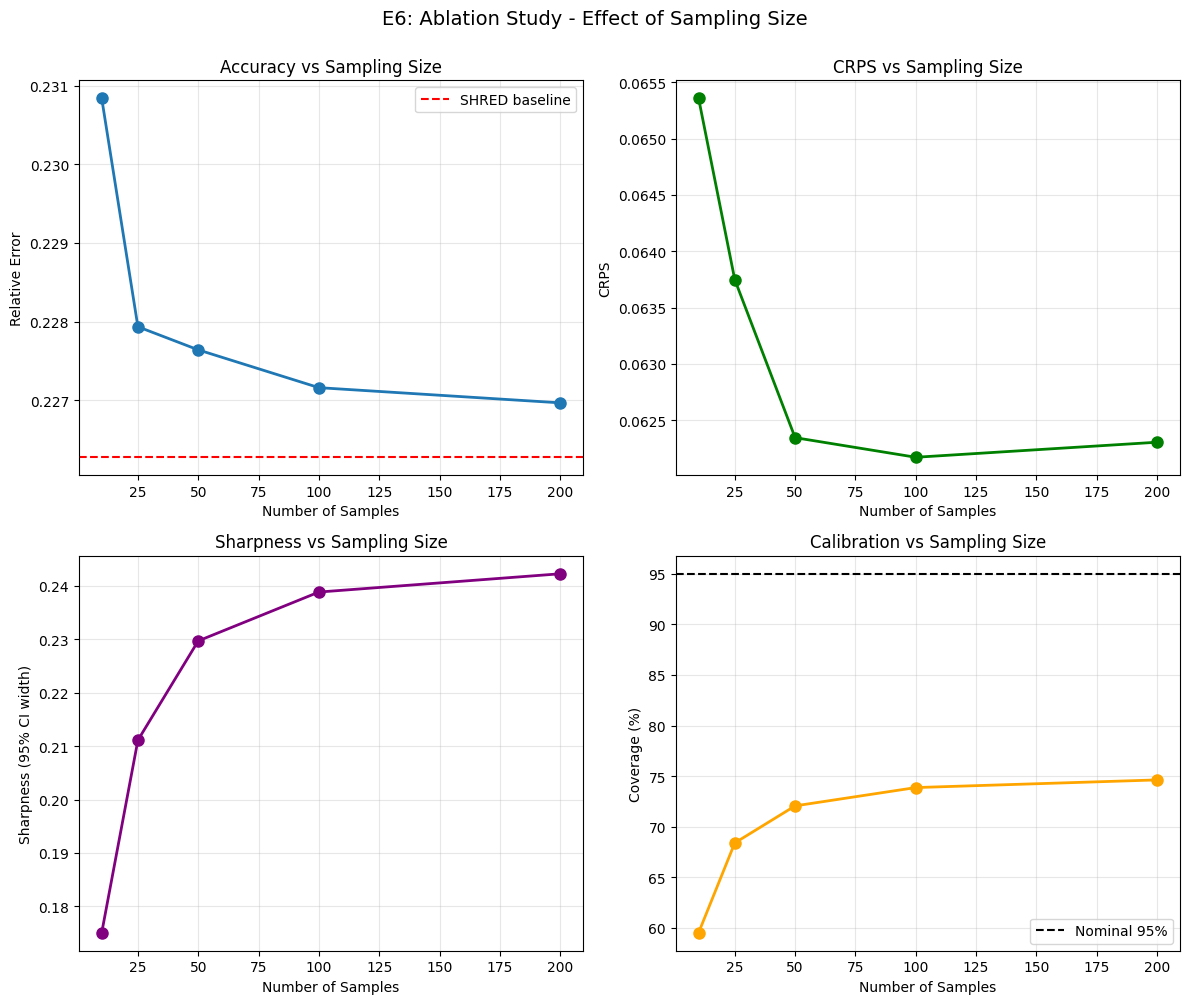

In [22]:
# E6 Visualization
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Relative error
axes[0, 0].plot(n_samp_arr, rel_err_arr, 'o-', linewidth=2, markersize=8)
axes[0, 0].axhline(shred_error, color='r', linestyle='--', label='SHRED baseline')
axes[0, 0].set_xlabel('Number of Samples')
axes[0, 0].set_ylabel('Relative Error')
axes[0, 0].set_title('Accuracy vs Sampling Size')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# CRPS
axes[0, 1].plot(n_samp_arr, crps_arr, 'o-', linewidth=2, markersize=8, color='green')
axes[0, 1].set_xlabel('Number of Samples')
axes[0, 1].set_ylabel('CRPS')
axes[0, 1].set_title('CRPS vs Sampling Size')
axes[0, 1].grid(alpha=0.3)

# Sharpness
axes[1, 0].plot(n_samp_arr, sharp_arr, 'o-', linewidth=2, markersize=8, color='purple')
axes[1, 0].set_xlabel('Number of Samples')
axes[1, 0].set_ylabel('Sharpness (95% CI width)')
axes[1, 0].set_title('Sharpness vs Sampling Size')
axes[1, 0].grid(alpha=0.3)

# Coverage
axes[1, 1].plot(n_samp_arr, cov_arr, 'o-', linewidth=2, markersize=8, color='orange')
axes[1, 1].axhline(95, color='k', linestyle='--', label='Nominal 95%')
axes[1, 1].set_xlabel('Number of Samples')
axes[1, 1].set_ylabel('Coverage (%)')
axes[1, 1].set_title('Calibration vs Sampling Size')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)

plt.suptitle('E6: Ablation Study - Effect of Sampling Size', fontsize=14, y=1.00)
plt.tight_layout()
plt.savefig(f'{results_dir}/E6_ablation_sampling_size.png', dpi=150)
plt.show()

---
# Summary and Export

In [23]:
# Comprehensive summary table
summary_lines = []
summary_lines.append('=' * 90)
summary_lines.append('UQ-SHRED COMPREHENSIVE RESULTS SUMMARY')
summary_lines.append('=' * 90)
summary_lines.append(f'Dataset: {dataset_name}')
summary_lines.append(f'Timestamp: {timestamp}')
summary_lines.append(f'Sensors: {num_sensors}, Lags: {lags}')
summary_lines.append(f'Train/Valid/Test: {len(train_indices)}/{len(valid_indices)}/{len(test_indices)}')
summary_lines.append('')
summary_lines.append('─' * 90)
summary_lines.append('E1: RECONSTRUCTION COMPARISON')
summary_lines.append('─' * 90)
summary_lines.append(f'{"Metric":<35} {"SHRED":<20} {"UQ Mean":<20} {"UQ Median":<20}')
summary_lines.append('-' * 90)
summary_lines.append(f'{"Relative Error":<35} {shred_error:<20.4f} {uq_mean_error:<20.4f} {uq_median_error:<20.4f}')
summary_lines.append(f'{"CRPS":<35} {"---":<20} {crps_score:<20.4f} {"---":<20}')
summary_lines.append(f'{"Sharpness (95% CI)":<35} {"---":<20} {sharp:<20.4f} {"---":<20}')
summary_lines.append(f'{"Coverage (95% CI)":<35} {"---":<20} {cal_scores[0.95]*100:<19.1f}% {"---":<20}')
summary_lines.append(f'{"UQ-Error Correlation":<35} {"---":<20} {corr:<20.3f} {"---":<20}')
summary_lines.append('')
summary_lines.append('─' * 90)
summary_lines.append('E2: CALIBRATION')
summary_lines.append('─' * 90)
for level, obs in cal_scores.items():
    summary_lines.append(f'  {level*100:>3.0f}% CI → {obs*100:>5.1f}% coverage')
summary_lines.append('')
summary_lines.append('─' * 90)
summary_lines.append('E3: UNCERTAINTY-ERROR RELATIONSHIP')
summary_lines.append('─' * 90)
summary_lines.append(f'  Correlation ρ(σ, |y-ŷ|): {corr:.4f}')
summary_lines.append('')
summary_lines.append('─' * 90)
summary_lines.append('E4: SPATIAL UNCERTAINTY')
summary_lines.append('─' * 90)
summary_lines.append(f'  Mean spatial uncertainty: {avg_std.mean():.4f}')
summary_lines.append(f'  Max spatial uncertainty:  {avg_std.max():.4f}')
summary_lines.append(f'  Min spatial uncertainty:  {avg_std.min():.4f}')
summary_lines.append('')
summary_lines.append('─' * 90)
summary_lines.append('E5: TEMPORAL FORECASTING')
summary_lines.append('─' * 90)
summary_lines.append(f'{"Metric":<35} {"SHRED":<20} {"UQ Mean":<20} {"UQ Median":<20}')
summary_lines.append('-' * 90)
summary_lines.append(f'{"Forecast Relative Error":<35} {shred_fc_error:<20.4f} {uq_mean_fc_error:<20.4f} {uq_median_fc_error:<20.4f}')
summary_lines.append('')
summary_lines.append('─' * 90)
summary_lines.append('E6: ABLATION STUDY (SAMPLING SIZE)')
summary_lines.append('─' * 90)
summary_lines.append(f'{"n_samples":<12} {"Rel Error":<12} {"CRPS":<12} {"Sharpness":<12} {"Coverage":<12}')
summary_lines.append('-' * 90)
for r in ablation_results:
    summary_lines.append(f'{r["n_samples"]:<12} {r["rel_error"]:<12.4f} {r["crps"]:<12.4f} {r["sharpness"]:<12.4f} {r["coverage_95"]*100:<11.1f}%')
summary_lines.append('=' * 90)

summary_text = '\n'.join(summary_lines)
print(summary_text)

# Save metrics
with open(f'{results_dir}/comprehensive_metrics.txt', 'w') as f:
    f.write(summary_text + '\n')

# Save config
with open(f'{results_dir}/config.json', 'w') as f:
    json.dump(config, f, indent=2)

# Save ablation results
with open(f'{results_dir}/ablation_results.json', 'w') as f:
    json.dump(ablation_results, f, indent=2)

print(f'\n✓ All results saved to: {results_dir}/')
print('\nGenerated files:')
print('  - comprehensive_metrics.txt')
print('  - config.json')
print('  - ablation_results.json')
print('  - E1_reconstruction_comparison.png')
print('  - E2_calibration_diagram.png')
print('  - E3_uncertainty_vs_error.png')
print('  - E4_spatial_uncertainty.png')
print('  - E4_spatial_snapshot.png')
print('  - E5_forecast_comparison.png')
print('  - E5_uncertainty_growth.png')
print('  - E6_ablation_sampling_size.png')

UQ-SHRED COMPREHENSIVE RESULTS SUMMARY
Dataset: SST
Timestamp: 20260224_111528
Sensors: 3, Lags: 52
Train/Valid/Test: 1078/134/136

──────────────────────────────────────────────────────────────────────────────────────────
E1: RECONSTRUCTION COMPARISON
──────────────────────────────────────────────────────────────────────────────────────────
Metric                              SHRED                UQ Mean              UQ Median           
------------------------------------------------------------------------------------------
Relative Error                      0.2263               0.2269               0.2289              
CRPS                                ---                  0.0622               ---                 
Sharpness (95% CI)                  ---                  0.2440               ---                 
Coverage (95% CI)                   ---                  74.9               % ---                 
UQ-Error Correlation                ---                  0.211        